In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv('/content/Food_Delivery_Time_Prediction.csv')

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [4]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757


In [8]:
if {'Restaurant_Latitude','Restaurant_Longitude','Delivery_Latitude','Delivery_Longitude'}.issubset(df.columns):

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371

        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))

        return R * c

    df['Calculated_Distance'] = haversine(
        df['Restaurant_Latitude'],
        df['Restaurant_Longitude'],
        df['Delivery_Latitude'],
        df['Delivery_Longitude']
    )

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757


In [9]:
if 'Order_Hour' in df.columns:

    df['Rush_Hour'] = df['Order_Hour'].apply(
        lambda x: 1 if x in [7,8,9,17,18,19] else 0
    )

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757


In [10]:
threshold = df['Delivery_Time'].median()

df['Delivery_Status'] = (
    df['Delivery_Time'] > threshold
).astype(int)

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403,0
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810,0
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332,0
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532,1
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,0


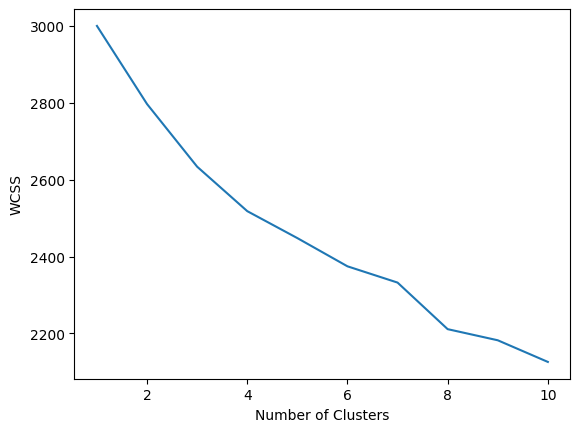

In [11]:
X_cluster = df.drop(columns=['Delivery_Status'])

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_cluster)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster)

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status,KMeans_Cluster
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403,0,0
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810,0,0
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332,0,2
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532,1,0
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,0,0


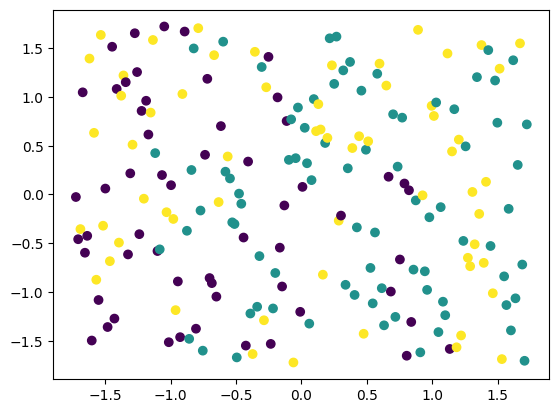

In [13]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['KMeans_Cluster']
)

plt.show()

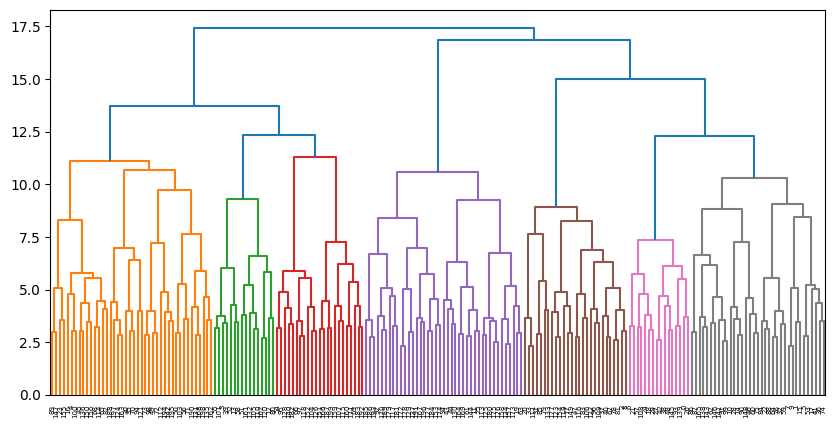

In [14]:
linked = linkage(X_cluster, method='ward')

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.show()

In [15]:
hc = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Cluster'] = hc.fit_predict(X_cluster)

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status,KMeans_Cluster,Hierarchical_Cluster
0,-1.723412,-0.025981,-1.550205,-1.454738,-0.511976,1.193481,-0.456512,1.209952,-1.199112,1.280048,0.515500,-0.987317,-1.487932,0.501852,1.192403,0,0,0
1,-1.706091,-0.458999,-0.857376,1.439192,-1.426220,1.193481,1.004325,-0.057013,1.465581,1.280048,1.085900,0.738511,-0.264987,-1.634294,-0.600810,0,0,0
2,-1.688771,-0.355075,1.099866,-0.666417,0.402267,1.193481,1.369535,-1.323979,1.465581,0.043287,-0.625302,-0.412041,-0.741529,1.092646,0.599332,0,2,0
3,-1.671450,1.047904,0.129905,0.335835,-1.426220,-0.110870,-1.186930,1.209952,-0.310881,0.043287,-0.767902,0.019416,1.382411,-0.923323,1.113532,1,0,1
4,-1.654129,-0.597565,-0.493641,-0.700119,-0.511976,-1.415221,0.273907,-0.057013,1.465581,0.043287,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,0,0,1


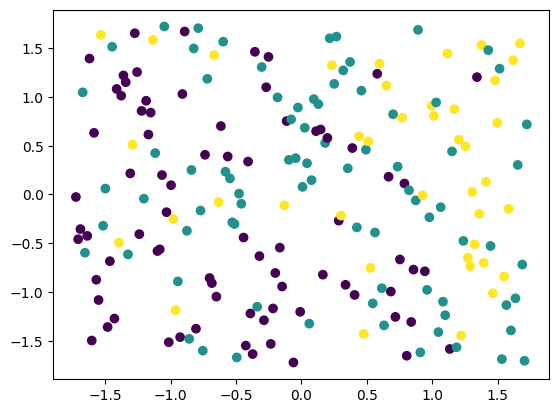

In [16]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['Hierarchical_Cluster']
)

plt.show()

In [17]:
X = df.drop(columns=['Delivery_Status'])
y = df['Delivery_Status']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4219 - loss: 0.7580 - val_accuracy: 0.7812 - val_loss: 0.6538
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5547 - loss: 0.7039 - val_accuracy: 0.8125 - val_loss: 0.6301
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6627 - val_accuracy: 0.7812 - val_loss: 0.6069
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7109 - loss: 0.6252 - val_accuracy: 0.7812 - val_loss: 0.5836
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7656 - loss: 0.5889 - val_accuracy: 0.7500 - val_loss: 0.5615
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8047 - loss: 0.5560 - val_accuracy: 0.8125 - val_loss: 0.5402
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8359 - loss: 0.5241 - val_accuracy: 0.8125 - val_loss: 0.5197
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8594 - loss: 0.4954 - val_accuracy: 0.8125 - val_loss: 0.4983


In [21]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.825
Precision: 0.85
Recall: 0.8095238095238095
F1 Score: 0.8292682926829268


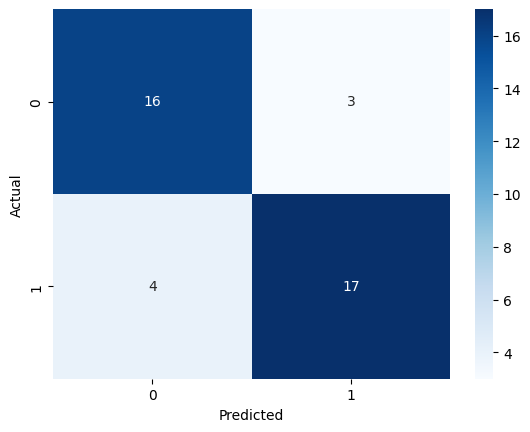

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

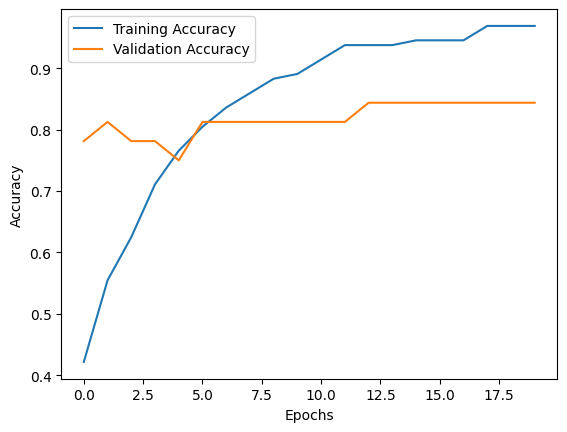

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

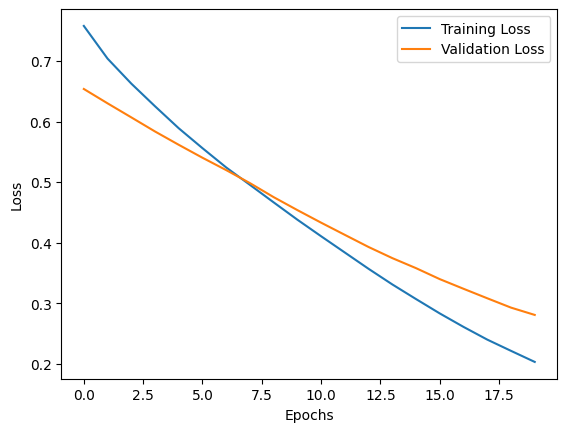

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [26]:
print("Actionable Insights:")
print("1. Traffic conditions significantly affect delivery delays.")
print("2. Delivery clustering helps identify delivery patterns.")
print("3. Neural Networks improve prediction performance.")
print("4. Optimizing routes can reduce delayed deliveries.")

Actionable Insights:
1. Traffic conditions significantly affect delivery delays.
2. Delivery clustering helps identify delivery patterns.
3. Neural Networks improve prediction performance.
4. Optimizing routes can reduce delayed deliveries.
